# An introduction to grids and raster data

## Overview

In this tutorial we will learn what gridded or raster data is, how it is structured and how to navigate it.

We focus on the concept of raster data rather than on the file formats and tools used to work with this kind of data.  We do this because while many of the tools commonly used to work with raster data (e.g. `xarray` and `rasterio`) make working with this kind of data easy, they also obscure a lot of the nuances of working with this data.  We will use the Python `numpy` and `matplotlib` packages in this tutorial.  However, we recommend that if you are working with raster and gridded data as part of your workflow, you use `xarray` or `rasterio`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## What is a raster?

A _raster_ is a rectangular grid of cells or _pixels_.  Pixels are arranged in _columns_ and _rows_.  The grid is defined by the number of columns and rows.

We can create a simple raster using `numpy`.  Here, we use the `numpy.ones` method to create a 6 by 6 grid (or array) where each element of that array has the value 1.

In [2]:
r = np.ones((6,6))
r

array([[1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.]])

We can access a _pixel_ by using the _row_ and _column_ index of the pixel.  In Python, _row_ and _column_ _indices_ are zero-based, that is they start at 0.  So to set the value of the pixel in the 3rd row and 5th column to zero, we would use the row index 2 and column index 4.

In [3]:
r[2,4] = 0
r

array([[1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.]])

We can see that the array element at (2,4) has been changed to zero.  However, we can see that the new zero element is in the third row counting from the top of the array.  This is perhaps unexpected if you were thinking in terms of a cartesian plane, where the origin is usually at the bottom left.

Some rasters do have their origins in the _bottom-left_ but by convention most images and grids (and numpy arrays) count from the _top-left_.

We can use `matplotlib.pyplot.imshow` to display our _raster_ `r`.  We'll add the pixel boundaries using `axhline` and `axvline`.

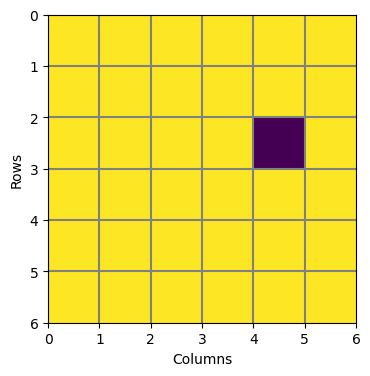

In [4]:
fig, ax = plt.subplots(figsize=(4,4))

ax.imshow(r, extent=[0,6,6,0])  # Set extent so that (0,0) is upper-left corner

[ax.axhline(y, c="0.5") for y in np.arange(0,6,1)]
[ax.axvline(x, c="0.5") for x in np.arange(0,6,1)]

ax.set_xlabel("Columns")
ax.set_ylabel("Rows");

Try setting some of the other pixels to zero.

## Image Coordinates

So far, we have accessed pixel values in the raster `r` using row and column indices; for example the 3rd row and 4th column.  If `r` contained data that represented, for example, elevation or land cover, we need a way to relate a point with coordinates that may not be whole rows or columns.  For example, a point with cordinates `(2.3, 4.7)`.  We are still thinking in row and column space but the coordinates are no longer whole numbers for indices of `r` but values on a continuous scale.  The point `(2.3,4.7)` is in _image coordinates_.

We can plot this point on `r` using the same plotting code as above.

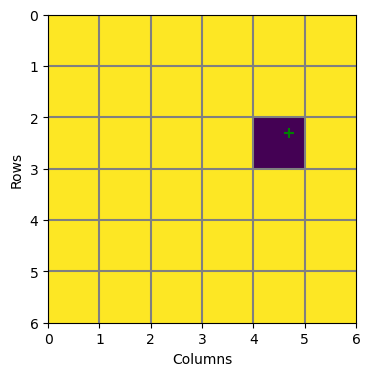

In [5]:
point = (2.3, 4.7)

fig, ax = plt.subplots(figsize=(4,4))

ax.imshow(r, extent=[0,6,6,0])  # Set extent so that (0,0) is upper-left corner
ax.scatter(point[1], point[0], s=50, c="g", marker="+")

[ax.axhline(y, c="0.5") for y in np.arange(0,6,1)]
[ax.axvline(x, c="0.5") for x in np.arange(0,6,1)]

ax.set_xlabel("Columns")
ax.set_ylabel("Rows");

Note that for plotting points or lines using `matplotlib`, the coordinates of the point are given to `scatter` as column for the _x-value_ and row as the _y-value_.  This can get confusing.  

Because our row and column indices are zero-based, we can convert the coordinates (2.3,4.7) to row and column indices by rounding the values down to the nearest integer to the values using the `floor` function.  As well as getting the integer part, we also need to convert each value to an integer type because numpy array require indices to be integers.

In [6]:
i, j = [np.floor(v).astype(int) for v in point]
r[i,j]

np.float64(0.0)

## Georeferencing a Raster

Georeferencing is the process of assigning real-world coordinates to a raster dataset, so that the data are tied to a location on Earth.  In other words, we want to be able to plot our raster, `r`, on a map.  We may also want to relate our raster to other georeferenced data or even visit the area covered by the raster in the field.

We will assume that the _real-world coordinates_ are in the standard CONUS Albers Equal Area Projection.  This is one of the standard map projections used for creating maps of the contiguous United States of America.

Mathematically, georeferencing is a transformation from an image coordinate system, in which points in the image are referenced by row and column indices, to a _projected_ coordinate system, in which those same points are referenced by $x$ and $y$ coordinates in units of distance.  In this case meters because this is the standard unit for the CONUS Albers Equal Area Projection.

We need to define a set of equations to convert columns to values of $x$ in meters and rows to values of $y$ in meters.  To do this, we need to know the _width_ and _height_ of a pixel, and the $x$ and $y$ coordinates of the origin of the image, e.g. the $x$ and $y$ of the upper-left corner of upper-left pixel of `r`.  With this information, we can use the following equations to get $x$ and $y$ for any point in the image.

$$
\begin{align}
x &= (column \times cell\_width) + upper\_left\_x  \\
y &= (row \times cell\_height) + upper\_left\_y
\end{align}
$$

The pixel width and height and coordinates of the upper-left corner of the upper-left pixel for `r` are:

In [9]:
cell_width = 100000.
cell_height = -100000.
upper_left_x = -1250000.
upper_left_y = 2340000.

We'll write two functions to convert row and column indices to $x$ and $y$.

In [10]:
def col2x(col):
    """Convert column index to x"""
    return col * cell_width + upper_left_x

def row2y(row):
    """Convert row index to y"""
    return row * cell_height + upper_left_y

We can test these to make sure we get the correct result by using the functions to get the $x$ and $y$ coordinates of the corners of the image. 

The coordinates for the corners in image coordinates are `(0,0)`, `(6,0)`, `(6,6)`, `(0,6)`, where the first value is the row and the second value is the column.  Below, we right the row to `i` and the column to `j`.  The image coordinate `(0,0)` should return the $x$ and $y$ of the upper-left corner of the upper-left pixel we defined above.

In [15]:
for p in [(0,0), (6,0), (6,6), (0,6)]:
    i, j = p
    print(f"Image ({i},{j}) --> Map ({col2x(j):10.1f},{row2y(i):10.1f})")

Image (0,0) --> Map (-1250000.0, 2340000.0)
Image (6,0) --> Map (-1250000.0, 1740000.0)
Image (6,6) --> Map ( -650000.0, 1740000.0)
Image (0,6) --> Map ( -650000.0, 2340000.0)


We can also check that total width and height of the image is 600,000 m.

Check that this is the case.

We can change the above code to get the extent of the image, which is the x coordinates for the left and right boundaries of the image, and the y coordinates for the bottom and top boundary of the image.

In [22]:
extent = [col2x(0), col2x(r.shape[1]), row2y(r.shape[0]), row2y(0)]
extent

[-1250000.0, -650000.0, 1740000.0, 2340000.0]

We can also get the $x$ and $y$ coordinates for each row and column.  These are just 1-dimensional arrays (or vectors) because the x coordinates for each row will be the same, and the y coordinates for each column will be the same.  

Usually, the $x$ and $y$ coordinates of pixels in an image are given for the center of the pixel.  So here, we start our row and column indices at 0.5.

In [37]:
x = [col2x(i) for i in np.arange(0.5,r.shape[1],1)]
y = [row2y(j) for j in np.arange(0.5,r.shape[0],1)]
x, y

([np.float64(-1200000.0),
  np.float64(-1100000.0),
  np.float64(-1000000.0),
  np.float64(-900000.0),
  np.float64(-800000.0),
  np.float64(-700000.0)],
 [np.float64(2290000.0),
  np.float64(2190000.0),
  np.float64(2090000.0),
  np.float64(1990000.0),
  np.float64(1890000.0),
  np.float64(1790000.0)])

Text(0, 0.5, 'y (m)')

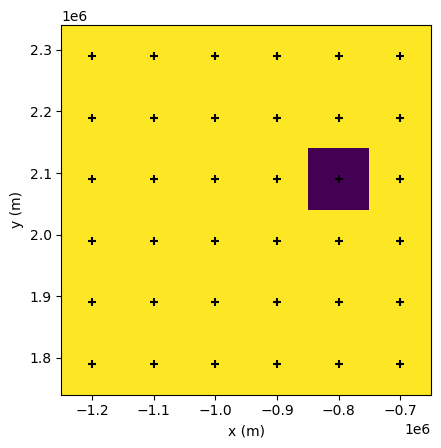

In [26]:
fig, ax = plt.subplots()
ax.imshow(r, extent=extent)
ax.scatter(*np.meshgrid(x, y), marker="+", color='k')
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

## Visualising the data

Now that we have defined the map coordinates for the raster `r` we can plot the data on a map.  We'll use the mapping package `cartopy` for this.  This package allows us to define a Coordinate Reference System using the `cartopy.crs` module.  It also allows us to add coastlines, state boundaries and other features to a map.

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

We define the CONUS Albers Equal Area projection.

In [27]:
projection = ccrs.AlbersEqualArea(
    central_longitude=-96.,
    central_latitude=23.,
    standard_parallels=[29.5, 45.5],
)

We then use `matplotlib` to make the map. We use the same `imshow` method we have been using above to display `r` but we set the image `extent` keyword to the extent we calculated in map units above.

The `ax.set_extent` sets the extent of the map we want to display, not the extent of the image

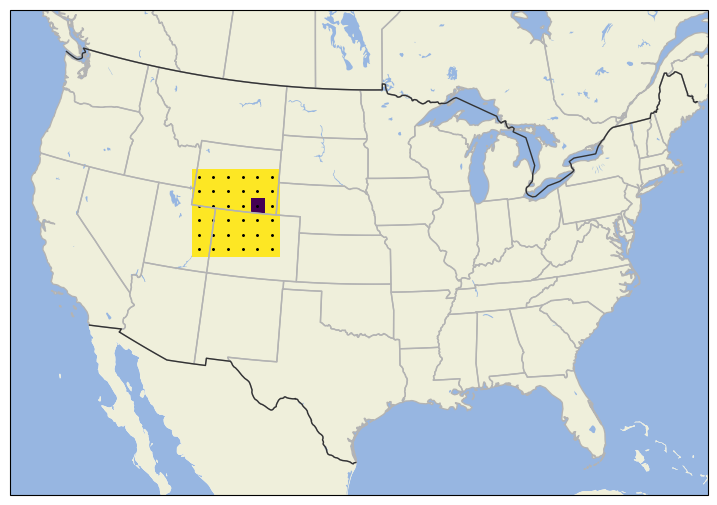

In [36]:
fig, ax = plt.subplots(
    subplot_kw = dict(projection=projection),
    figsize=(9,7),
)
ax.set_extent([-2500000., 2300000., 100000., 3440000.], projection)

ax.imshow(r, extent=extent)
ax.scatter(*np.meshgrid(x, y), marker=".", color='k', s=5)

ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.STATES, edgecolor="0.7")
ax.add_feature(cfeature.BORDERS, edgecolor="0.2");

As an example, let's assume our raster `r` covers a region spanning Wyoming, Utah and Colorado in the United States, as shown in the map below. 

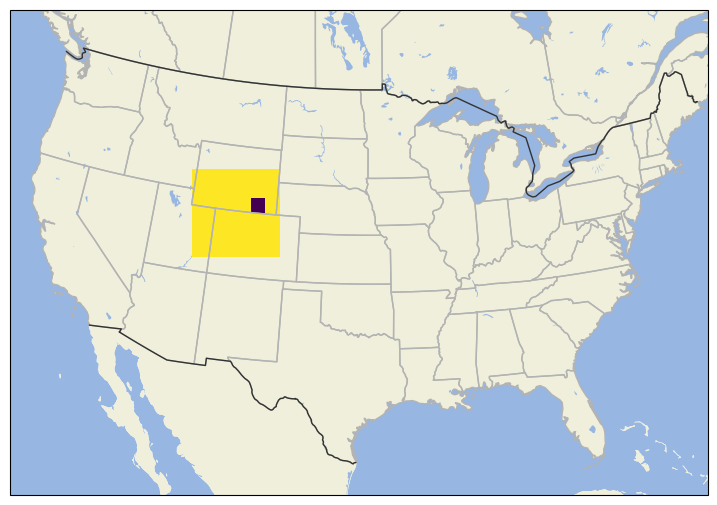

In [7]:
#| echo: false

cell_width = 100000.
cell_height = -100000.
upper_left_x = -1250000.
upper_left_y = 2340000.
    

fig, ax = plt.subplots(
    subplot_kw = dict(projection=projection),
    figsize=(9,7),
)
# ax.set_global()
ax.set_extent([-2500000., 2300000., 100000., 3440000.], projection)

ax.imshow(r, extent=[-1250000.0, -650000.0, 1740000.0, 2340000.0])

ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.STATES, edgecolor="0.7")
ax.add_feature(cfeature.BORDERS, edgecolor="0.2");

# Get x and y limits for plotting sequence
x_limits = ax.get_xlim()
y_limits = ax.get_ylim()

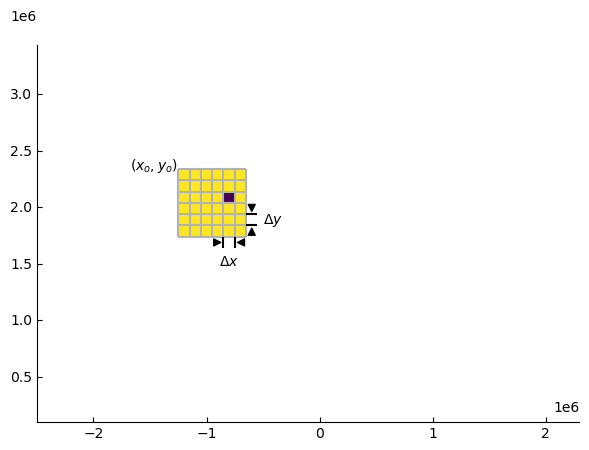

In [8]:
#| echo: false

from mpl_toolkits.axisartist.axislines import Axes
from affine import Affine

from grid_and_projection_plot_utils import add_image_grid, add_cell_width_marker


fwd = Affine(cell_width, 0., upper_left_x, 0., cell_height, upper_left_y)
    
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(axes_class=Axes))

ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_aspect("equal")

ax.axis["right"].set_visible(False)
ax.axis["top"].set_visible(False)

ax.imshow(r, extent=[-1250000.0, -650000.0, 1740000.0, 2340000.0])
# Add text for upper_left pixel coordinates
ax.annotate(r"$(x_{o},y_{o})$", (upper_left_x, upper_left_y), ha="right")

# Add grid lines for image pixels
add_image_grid(r, fwd, color="0.7")
add_cell_width_marker((5,6), fwd, dimension="width", color="k")
add_cell_width_marker((6,5), fwd, dimension="height", color="k")

In [40]:
lines = make_width_marker((6,6), fwd)

In [41]:
lines

[[(np.float64(-850000.0), np.float64(1740000.0)),
  (np.float64(-850000.0), np.float64(1640000.0))],
 [(np.float64(-750000.0), np.float64(1740000.0)),
  (np.float64(-750000.0), np.float64(1640000.0))]]

In [38]:
for line in lines:
    # for pt in line:
    #     print(pt)
    print(line)

[(np.float64(-850000.0), np.float64(1740000.0)), (np.float64(-850000.0), np.float64(1640000.0))]
[(np.float64(-750000.0), np.float64(1740000.0)), (np.float64(-750000.0), np.float64(1640000.0))]


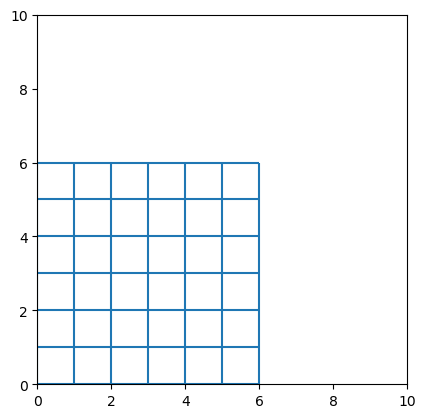

In [12]:
fig, ax = plt.subplots()
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_aspect("equal")

ax.add_collection(LineCollection(lines))

In [49]:
row = 0.
col = 0.
x = col * cell_width + upper_left_x
y = row * cell_height + upper_left_y
x, y

(-1250000.0, 2340000.0)

In [85]:
inv = ax.transAxes.inverted()
px, py = ax.transData.transform((upper_left_x, upper_left_y))
ax, ay = inv.transform((px, py))
ax, ay

(np.float64(0.26041666666666674), np.float64(0.6706586826347307))

In [39]:
import matplotlib.image as mimage

img = mimage.imread("../example_data/960px-John_Constable_-_The_Hay_Wain_(1821).jpg")

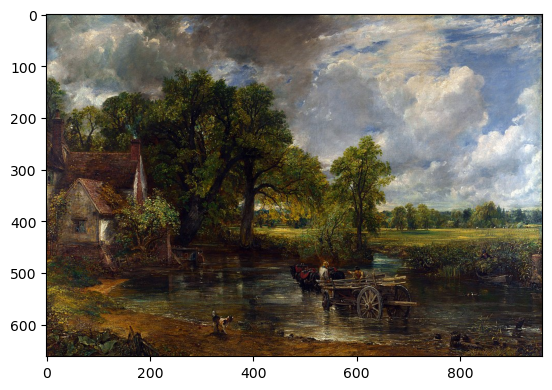

In [40]:
plt.imshow(img)

In [41]:
img.shape

(662, 960, 3)

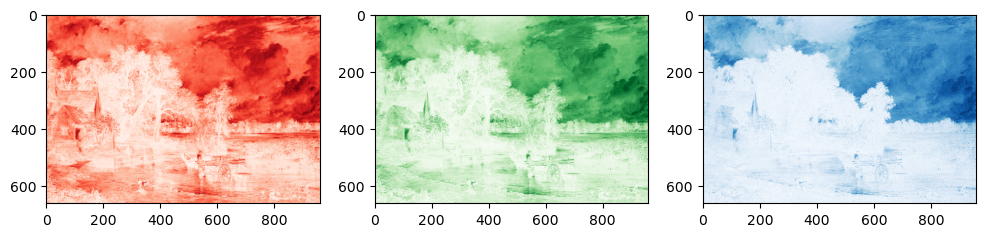

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(12,5))

ax[0].imshow(img[:,:,0], cmap="Reds")
ax[1].imshow(img[:,:,1], cmap="Greens")
ax[2].imshow(img[:,:,2], cmap="Blues")

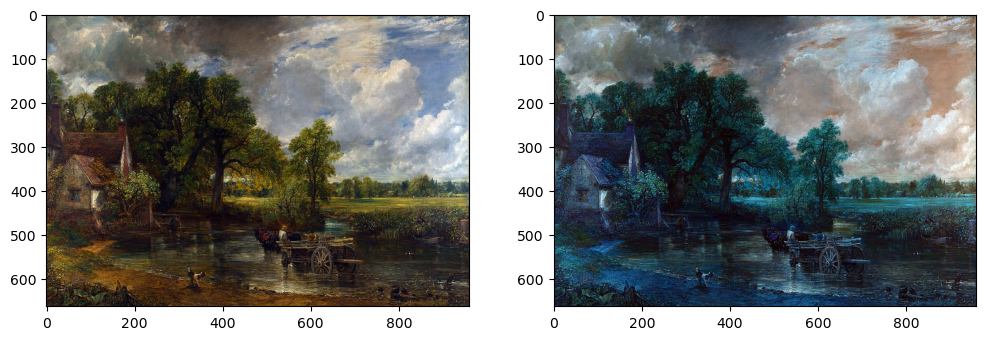

In [52]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].imshow(img)
ax[1].imshow(img[:,:,[2,1,0]])